
# 88 Gastronorm "many objects" — FFT magnitude analysis

Dataset: `experiments/2026_09_23_gastronorm_many_objects/` — 19 object types, each
captured at 7-8 xy positions x 4 speakers (~28-32 samples/object), plus 24 empty-box
captures (6 positions x 4 speakers: 3 positions at the start of the session, 3 repeated
at the end). We work with the **FFT magnitude averaged over the 100 lasers and the 2
x/y channels** — i.e. `mean(|FFT|, axis=(laser, xy))` -> one `(1235,)` spectrum per
sample (`vibration/04_ffts.npz`, shape `(1, 100, 1235, 2)` complex).

## Questions & methods




| # | Question | Method |
|---|----------|--------|
| 1 | Does signal shift more between **position** or **object type**? | PERMANOVA (permutation F-test + R^2) on object-type as a between-group factor vs. position-within-object as a nested factor, on log-magnitude spectra. Cross-checked with a PCA scatter colored by each factor. |
| 2 | How does the empty box before vs. after compare? | Baseline-relative distance: before (positions 1-3, session start) vs. after (positions 141-143, session end) mean spectra, compared against each half's own internal (speaker) spread as a noise floor. |
| 3 | For the coffee pot, how does signal change as we move it around? | Distance of each of its 7 positions from its own mean spectrum, plotted against xy position. |
| 4 | Which object changes the signal the most / least vs. the empty box? | Baseline-relative distance ranking: RMS log-magnitude distance of each object's mean spectrum from the empty-box mean, ranked bar chart. |
| 5 | Do all objects have the same signal near the center? How consistent — give a number. | Every object has 3 near-center replicate positions. Compare within-object spread at center (repeatability / noise floor) against across-object spread of center spectra (do different objects converge to the same signal there), reported as a ratio. |

We intentionally do **not** attempt one global position x object ANOVA: positions are
(mostly) unique to a given object (nested design, not fully crossed), except for the
empty-box repeats and each object's own near-center repeats — so factor 1's test is a
nested PERMANOVA rather than a two-way one.

# 0 Imports & config

In [1]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220, "display.max_columns", 80)

REPO = Path.cwd().parent
DATASET_DIR = REPO / "experiments/2026_09_23_gastronorm_many_objects"
SAMPLES_DIR = DATASET_DIR / "samples"
assert SAMPLES_DIR.is_dir(), SAMPLES_DIR

RNG = np.random.default_rng(0)
N_PERM = 999          # PERMANOVA permutations

DIST_METRIC = os.environ.get("DIST_METRIC", "euclidean")   # "euclidean" or "cosine"
assert DIST_METRIC in ("euclidean", "cosine")
print(f"DIST_METRIC = {DIST_METRIC}  (override with the DIST_METRIC env var, e.g. DIST_METRIC=cosine jupyter ...)")

DIST_METRIC = euclidean  (override with the DIST_METRIC env var, e.g. DIST_METRIC=cosine jupyter ...)


# 1 Load metadata + FFT magnitude spectra

One row per sample: metadata (`position_id`, `speaker`, `object_type`, `is_empty_box`,
`avg_com`) plus the averaged spectrum `mag = mean(|FFT|, axis=(laser, xy))`, shape
`(1235,)`, and its log (floored at the 1st percentile so empty bins don't blow up).

In [2]:
def read_metadata(sample_dir: Path) -> dict:
    meta = {}
    for line in (sample_dir / "metadata.jsonl").read_text().splitlines():
        line = line.strip()
        if line:
            meta.update(json.loads(line))
    return meta


def parse_com(v):
    if not v:
        return None
    parts = np.asarray(v, dtype=float).ravel().tolist()
    return parts[:2] if len(parts) >= 2 else None


def avg_fft_mag(fft_path: Path):
    """mean(|FFT|, axis=(laser, xy)) -> (freqs, mag), mag shape (F,)."""
    with np.load(fft_path) as z:
        fft, freqs = z["fft"], z["freqs"]
    mag = np.abs(fft[0]).mean(axis=(0, 2))     # (1,L,F,C) -> (F,)
    return freqs, mag


def to_logmag(mag: np.ndarray) -> np.ndarray:
    floor = np.percentile(mag, 1)
    return np.log(np.maximum(mag, floor))


rows, mags = [], []
for sample_dir in sorted(p for p in SAMPLES_DIR.glob("*") if p.is_dir()):
    fft_path = sample_dir / "vibration/04_ffts.npz"
    if not (sample_dir / "metadata.jsonl").exists() or not fft_path.exists():
        continue
    meta = read_metadata(sample_dir)
    objects = meta.get("objects") or {}
    freqs, mag = avg_fft_mag(fft_path)
    rows.append(dict(
        sample_id=meta["sample_id"],
        position_id=int(meta["position_id"]),
        speaker=meta["speaker"],
        is_empty_box=bool(meta.get("is_empty_box")),
        object_type=next(iter(objects), None),
        timestamp=meta.get("timestamp"),
        com=parse_com(meta.get("avg_com")),
    ))
    mags.append(mag)

df = pd.DataFrame(rows)
df["com0"] = [c[0] if c else np.nan for c in df["com"]]
df["com1"] = [c[1] if c else np.nan for c in df["com"]]
FREQS = freqs                                   # shared freq grid, (1235,)
MAG = np.stack(mags)                            # (N, 1235) linear avg magnitude
LOGMAG = np.stack([to_logmag(m) for m in mags])  # (N, 1235)

print(f"{len(df)} samples, {df['object_type'].nunique()} object types, "
      f"{df['is_empty_box'].sum()} empty-box, {df['position_id'].nunique()} positions")
df.groupby("object_type", dropna=False).size().sort_values(ascending=False)

556 samples, 19 object types, 24 empty-box, 139 positions


object_type
biscoff           28
book              28
candle            28
coffee can        28
coffee pot        28
cube              28
cylinder          28
cylinder-100g     28
cylinder-200g     28
cylinder-500g     28
duct-tape         28
glass-cup         28
plant             28
quinoa            28
red-beans         28
ring              28
soap dispenser    28
tomato sauce      28
vase              28
NaN               24
dtype: int64

# 2 Distance matrix + PERMANOVA helper

Squared distance between log-magnitude spectra is the base metric for everything
below (PERMANOVA, ranking, consistency) — either **squared Euclidean** or, with
`DIST_METRIC=cosine`, **squared cosine distance** (`1 - cosine similarity`), which is
scale-invariant: it only cares about the *shape* of the spectrum, not its overall
level. PERMANOVA (Anderson 2001) works with either: pseudo-`F = (SS_among/(a-1)) /
(SS_within/(N-a))` computed straight from a squared distance matrix (any distance
measure, not just Euclidean), with a permutation null (shuffle group labels) for the
p-value and `R^2 = SS_among / SS_total` for effect size.

In [3]:
from scipy.spatial.distance import pdist, squareform


def sq_dist_matrix(X: np.ndarray, metric: str = None) -> np.ndarray:
    """Squared distance matrix, (N, N), using DIST_METRIC ('euclidean' or 'cosine')."""
    d = squareform(pdist(X, metric=metric or DIST_METRIC))
    return d ** 2


def _pseudo_F_R2(D2: np.ndarray, groups: np.ndarray):
    n = D2.shape[0]
    ss_total = D2[np.triu_indices(n, 1)].sum() / n
    ss_within = 0.0
    uniq = np.unique(groups)
    for u in uniq:
        idx = np.where(groups == u)[0]
        if len(idx) > 1:
            sub = D2[np.ix_(idx, idx)]
            ss_within += sub[np.triu_indices(len(idx), 1)].sum() / len(idx)
    ss_among = ss_total - ss_within
    a = len(uniq)
    F = (ss_among / (a - 1)) / (ss_within / (n - a))
    return F, ss_among / ss_total


def permanova(D2: np.ndarray, groups, n_perm: int = N_PERM, rng=RNG):
    """Returns (pseudo_F, R2, p_value) for `groups` on squared-distance matrix D2."""
    groups = np.asarray(groups)
    F_obs, R2_obs = _pseudo_F_R2(D2, groups)
    F_perm = np.empty(n_perm)
    for i in range(n_perm):
        F_perm[i], _ = _pseudo_F_R2(D2, rng.permutation(groups))
    p = (np.sum(F_perm >= F_obs) + 1) / (n_perm + 1)
    return F_obs, R2_obs, p


def spectral_dist(a: np.ndarray, b: np.ndarray, metric: str = None) -> np.ndarray:
    """Distance between rows of `a` and (broadcastable) `b`, per DIST_METRIC.
    'euclidean' -> RMS distance over the last axis (not the raw L2 norm).
    'cosine'    -> 1 - cosine similarity. Needs non-zero vectors (e.g. raw log-mag
    spectra or non-degenerate means), NOT a residual compared against the zero vector."""
    metric = metric or DIST_METRIC
    if metric == "cosine":
        num = np.sum(a * b, axis=-1)
        den = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
        return 1.0 - num / den
    return np.sqrt(np.mean((a - b) ** 2, axis=-1))


rms_dist = spectral_dist    # alias kept for readability at call sites below

## 1.1 The dominant confound: speaker identity

Before doing anything else: a quick PERMANOVA of `speaker` (the excitation source,
one of 4 per position) on the raw log-magnitude spectra explains far more variance
than object type or position (computed below, under whichever `DIST_METRIC` is
active). Each position was captured at 4 different speakers, and which speaker fired
dominates the averaged spectrum far more than what's in the box. Every question below
is therefore computed on **speaker-corrected residuals**: `resid = logmag - (that
sample's speaker's own empty-box mean)`. Each speaker has 6 empty-box captures (3 at
the session start, 3 at the end), giving every speaker its own silent baseline;
subtracting it removes the speaker main effect and leaves the part of the spectrum
actually driven by object / position.

In [4]:
empty_mask = df["is_empty_box"].to_numpy()
obj_mask = (~df["is_empty_box"]).to_numpy() & df["object_type"].notna().to_numpy()

D2_raw = sq_dist_matrix(LOGMAG[obj_mask])
_, R2_spk, p_spk = permanova(D2_raw, df.loc[obj_mask, "speaker"].to_numpy(), n_perm=499)
_, R2_obj_raw, _ = permanova(D2_raw, df.loc[obj_mask, "object_type"].to_numpy(), n_perm=499)
print(f"[{DIST_METRIC}] speaker R^2={R2_spk:.3f} (p={p_spk:.3f})  vs.  "
      f"object-type R^2={R2_obj_raw:.3f}  -- both on RAW (speaker-uncorrected) spectra")

empty_mean_by_speaker = {
    s: LOGMAG[empty_mask & (df["speaker"] == s).to_numpy()].mean(axis=0)
    for s in sorted(df["speaker"].unique())
}
speaker_baseline = np.stack([empty_mean_by_speaker[s] for s in df["speaker"]])
RESID = LOGMAG - speaker_baseline          # speaker-corrected residual spectrum, (N, 1235)

[euclidean] speaker R^2=0.884 (p=0.002)  vs.  object-type R^2=0.012  -- both on RAW (speaker-uncorrected) spectra


# 3 Q1 — does signal shift more between position or object type?

Positions are (mostly) nested within object, not crossed with it, so we run two
separate PERMANOVAs on the same distance metric:

- **Between-object**: group = `object_type`, over all non-empty samples. `R^2` = the
  fraction of total spectral variance explained by *which object* is in the box.
- **Position-within-object (nested)**: for each object separately, group = its own
  `position_id` (4 speaker-replicates per position). `R^2` = fraction of that
  object's own variance explained by *where* it sits. Averaged over all 19 objects.

Whichever `R^2` is larger is the dominant factor.

In [5]:
obj_mask = (~df["is_empty_box"]).to_numpy() & df["object_type"].notna().to_numpy()
X_obj = RESID[obj_mask]
D2_obj = sq_dist_matrix(X_obj)
F_obj, R2_obj, p_obj = permanova(D2_obj, df.loc[obj_mask, "object_type"].to_numpy())
print(f"BETWEEN-OBJECT   pseudo-F={F_obj:.2f}  R^2={R2_obj:.3f}  p={p_obj:.4f}  "
      f"(n={obj_mask.sum()}, {df.loc[obj_mask, 'object_type'].nunique()} objects)")

nested_rows = []
for obj, g in df[obj_mask].groupby("object_type"):
    idx = g.index.to_numpy()
    if g["position_id"].nunique() < 2:
        continue
    D2_sub = sq_dist_matrix(RESID[idx])
    F, R2, p = permanova(D2_sub, g["position_id"].to_numpy(), n_perm=499)
    nested_rows.append(dict(object_type=obj, n=len(g), n_positions=g["position_id"].nunique(),
                             F=F, R2=R2, p=p))
nested_df = pd.DataFrame(nested_rows).sort_values("R2", ascending=False).reset_index(drop=True)

print(f"\nPOSITION-WITHIN-OBJECT (nested), mean R^2={nested_df['R2'].mean():.3f}  "
      f"median R^2={nested_df['R2'].median():.3f}  "
      f"(significant at p<0.05 in {(nested_df['p'] < 0.05).sum()}/{len(nested_df)} objects)")
nested_df

BETWEEN-OBJECT   pseudo-F=2.26  R^2=0.074  p=0.0010  (n=532, 19 objects)



POSITION-WITHIN-OBJECT (nested), mean R^2=0.262  median R^2=0.265  (significant at p<0.05 in 5/19 objects)


,object_type,n,n_positions,F,R2,p
0,soap dispenser,28,7,1.724334,0.330058,0.022
1,vase,28,7,1.593330,0.312827,0.016
2,coffee pot,28,7,1.590460,0.312439,0.022
3,cube,28,7,1.466796,0.295320,0.038
4,cylinder,28,7,1.438085,0.291223,0.054
5,tomato sauce,28,7,1.418818,0.288447,0.052
6,ring,28,7,1.408868,0.287005,0.054
7,candle,28,7,1.394448,0.284904,0.034
8,red-beans,28,7,1.273122,0.266727,0.142
9,duct-tape,28,7,1.261059,0.264869,0.124


### PCA sanity-check

Left: all non-empty samples projected to 2D, colored by object type — tight,
separated clusters would mean object identity dominates. Right: the same PCA space,
but only the 3 objects with the most positions, colored by `position_id` instead —
spread within one color-blob here is the position effect.

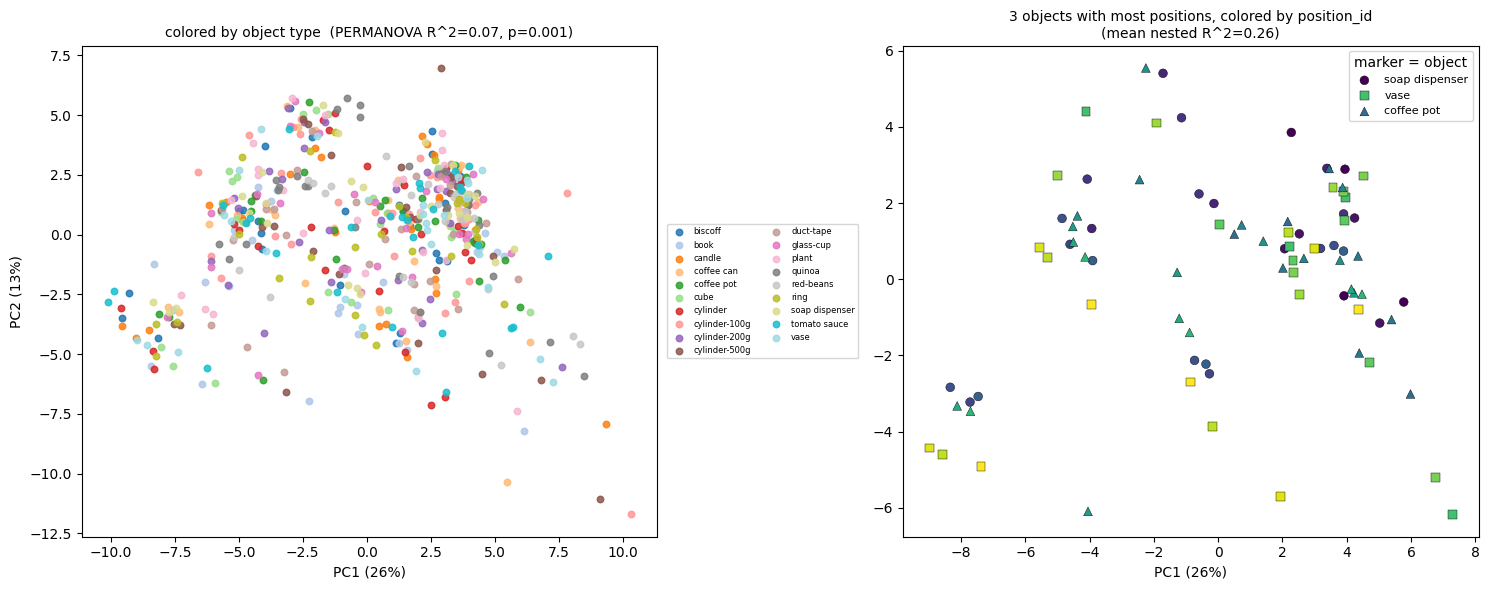

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(X_obj - X_obj.mean(axis=0))
obj_types = df.loc[obj_mask, "object_type"].to_numpy()
uniq_objs = sorted(set(obj_types))
cmap = plt.get_cmap("tab20", len(uniq_objs))
obj_color = {o: cmap(i) for i, o in enumerate(uniq_objs)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for o in uniq_objs:
    m = obj_types == o
    ax.scatter(Z[m, 0], Z[m, 1], s=22, color=obj_color[o], label=o, alpha=0.85)
ax.set_title(f"colored by object type  (PERMANOVA R^2={R2_obj:.2f}, p={p_obj:.3f})", fontsize=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.legend(fontsize=6, ncol=2, loc="center left", bbox_to_anchor=(1.01, 0.5))

top3 = nested_df.nlargest(3, "n_positions")["object_type"].tolist()
ax = axes[1]
sub_mask = np.isin(obj_types, top3)
positions_sub = df.loc[obj_mask, "position_id"].to_numpy()[sub_mask]
uniq_pos = sorted(set(positions_sub))
pcmap = plt.get_cmap("viridis", len(uniq_pos))
pos_color = {p: pcmap(i) for i, p in enumerate(uniq_pos)}
for i, o in enumerate(top3):
    m = obj_types == o
    marker = ["o", "s", "^"][i]
    ax.scatter(Z[m, 0], Z[m, 1], s=40, marker=marker,
               c=[pos_color[p] for p in df.loc[obj_mask, "position_id"].to_numpy()[m]],
               edgecolors="k", linewidths=0.3, label=o)
ax.set_title(f"3 objects with most positions, colored by position_id\n"
             f"(mean nested R^2={nested_df['R2'].mean():.2f})", fontsize=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax.legend(fontsize=8, title="marker = object")
fig.tight_layout()
plt.show()

### Per-class view: pairwise PERMANOVA

The single R^2=0.107 above is a joint statistic over all 19 groups at once (one
shared `SS_total`/`SS_within`) — it can't be decomposed back into "R^2 for object X."
What *does* give a genuine per-class number: run the same 2-group PERMANOVA between
every pair of objects (`a=2` in the same equations), giving each pair its own R^2 for
how separable those two specifically are. 19 objects -> 171 pairs -> a symmetric
19x19 heatmap: bright = easy to tell apart, dark = acoustically similar.

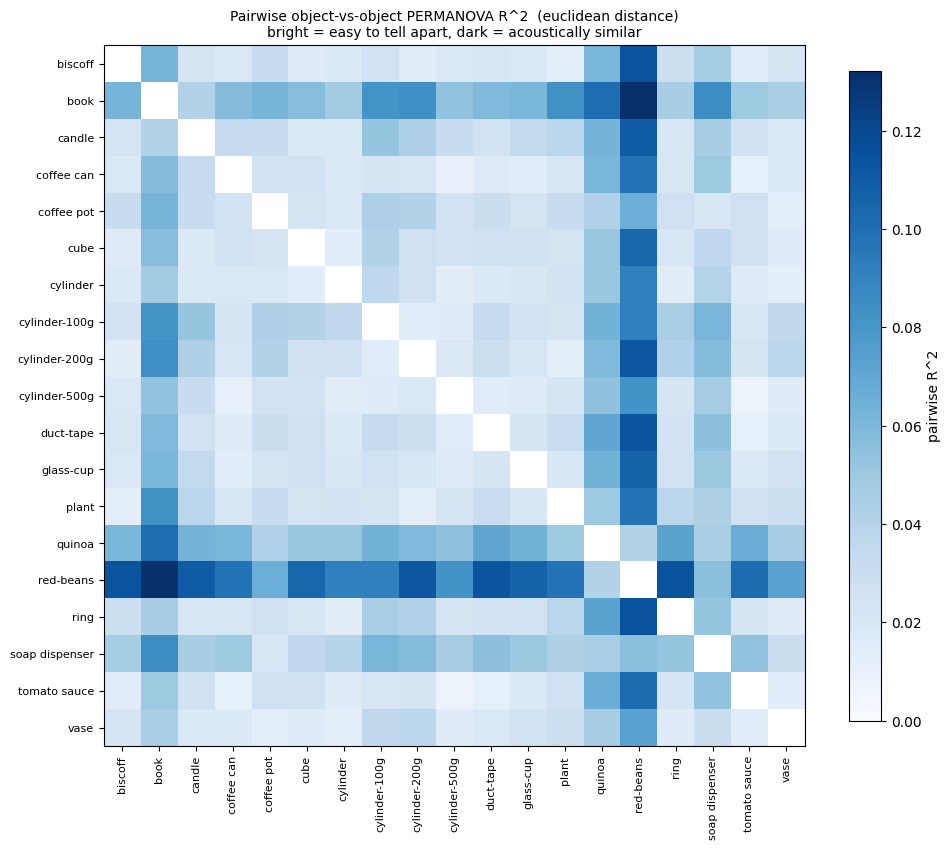

most confusable (lowest R^2):
            a             b       R2     p
cylinder-500g  tomato sauce 0.007600 0.995
   coffee can cylinder-500g 0.010656 0.875
    duct-tape  tomato sauce 0.010915 0.865
   coffee can  tomato sauce 0.011161 0.815
   coffee pot          vase 0.012431 0.715

most distinct (highest R^2):
            a         b       R2     p
cylinder-200g red-beans 0.112337 0.005
    duct-tape red-beans 0.113210 0.005
      biscoff red-beans 0.114086 0.005
    red-beans      ring 0.114453 0.005
         book red-beans 0.132218 0.005


In [7]:
pw_objs = sorted(uniq_objs)
n_pw = len(pw_objs)
R2_pw = np.full((n_pw, n_pw), np.nan)
p_pw = np.full((n_pw, n_pw), np.nan)

for i, oi in enumerate(pw_objs):
    for j, oj in enumerate(pw_objs):
        if j <= i:
            continue
        mask = np.isin(obj_types, [oi, oj])
        D2_pair = sq_dist_matrix(X_obj[mask])
        _, R2, p = permanova(D2_pair, obj_types[mask], n_perm=199)
        R2_pw[i, j] = R2_pw[j, i] = R2
        p_pw[i, j] = p_pw[j, i] = p

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(R2_pw, cmap="Blues", vmin=0)
ax.set_xticks(range(n_pw)); ax.set_xticklabels(pw_objs, rotation=90, fontsize=8)
ax.set_yticks(range(n_pw)); ax.set_yticklabels(pw_objs, fontsize=8)
ax.set_title(f"Pairwise object-vs-object PERMANOVA R^2  ({DIST_METRIC} distance)\n"
             "bright = easy to tell apart, dark = acoustically similar", fontsize=10)
fig.colorbar(im, ax=ax, label="pairwise R^2", shrink=0.8)
fig.tight_layout()
plt.show()

# most / least separable pairs
tri = np.triu_indices(n_pw, 1)
pairs = pd.DataFrame({"a": [pw_objs[i] for i in tri[0]], "b": [pw_objs[i] for i in tri[1]],
                       "R2": R2_pw[tri], "p": p_pw[tri]}).sort_values("R2")
print("most confusable (lowest R^2):")
print(pairs.head(5).to_string(index=False))
print("\nmost distinct (highest R^2):")
print(pairs.tail(5).to_string(index=False))

# 4 Q4 — which object changes the signal the most / least vs. the empty box?

For each object, RMS log-magnitude distance of every one of its samples from the
**pooled empty-box mean spectrum** (all 24 empty-box captures, all positions
pooled — a single reference since positions barely move the empty-box spectrum,
checked in section 6). Ranked bar chart, error bars = spread across that object's
own samples.

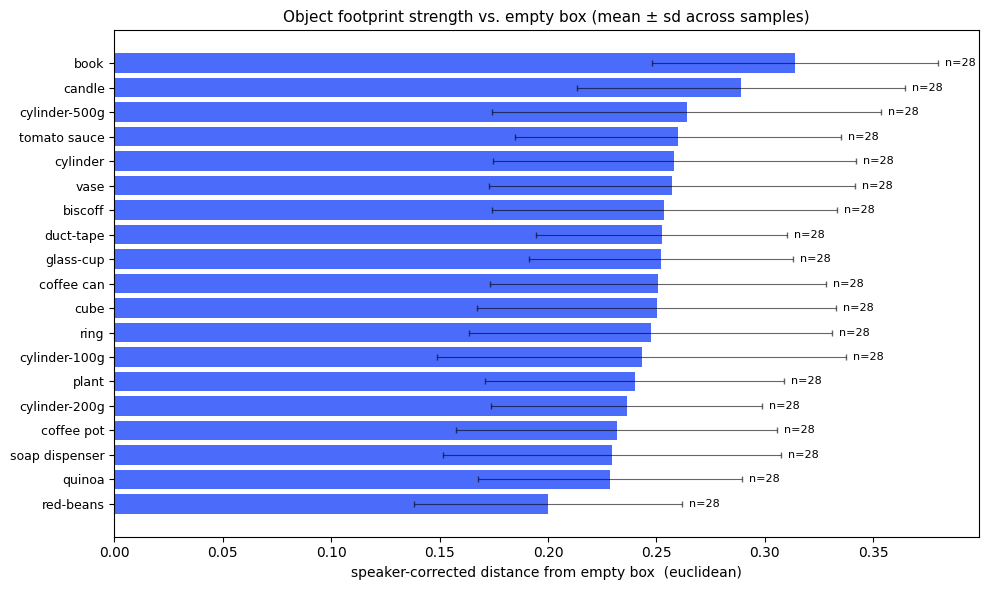

Most different from empty box: book (0.314)
Least different from empty box: red-beans (0.200)
reference: empty-box samples' own residual distance (noise floor) = 0.118


,mean,std,count
object_type,,,
book,0.313962,0.065903,28
candle,0.289029,0.075441,28
cylinder-500g,0.263898,0.089634,28
tomato sauce,0.259956,0.075354,28
cylinder,0.258307,0.083754,28
vase,0.257170,0.084401,28
biscoff,0.253635,0.079462,28
duct-tape,0.252482,0.057943,28
glass-cup,0.252155,0.060866,28


In [8]:
# distance(LOGMAG, this sample's speaker baseline) -- NOT rms_dist(RESID, 0), since
# cosine distance to the zero vector is undefined; this form works for either metric.
df["dist_from_empty"] = rms_dist(LOGMAG, speaker_baseline)

rank = (df[obj_mask].groupby("object_type")["dist_from_empty"]
        .agg(["mean", "std", "count"]).sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rank))
ax.barh(y, rank["mean"], xerr=rank["std"], color="#4b6bfb", capsize=2, error_kw=dict(lw=0.8, alpha=0.6))
ax.set_yticks(y); ax.set_yticklabels(rank.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel(f"speaker-corrected distance from empty box  ({DIST_METRIC})")
ax.set_title("Object footprint strength vs. empty box (mean ± sd across samples)", fontsize=11)
for yi, (m, s, n) in zip(y, rank.itertuples(index=False)):
    ax.text(m + s, yi, f"  n={n}", va="center", fontsize=8)
fig.tight_layout()
plt.show()

print(f"Most different from empty box: {rank.index[0]} ({rank['mean'].iloc[0]:.3f})")
print(f"Least different from empty box: {rank.index[-1]} ({rank['mean'].iloc[-1]:.3f})")
print(f"reference: empty-box samples' own residual distance (noise floor) = {df.loc[empty_mask, 'dist_from_empty'].mean():.3f}")
rank

# 5 Q2 — empty box before vs. after

Positions 1-3 were captured at the very start of the session (`~16:37`), positions
141-143 at the very end (`~18:20`), each at 4 speakers — a natural before/after
repeatability check. We compare the before-vs-after mean-spectrum distance against
each half's own internal (across-speaker) spread, which is the measurement noise
floor.

before: 12 samples, after: 12 samples
before-vs-after distance:      0.1172
within-half noise floor:       0.1016
ratio (signal / noise floor):  1.15x
PERMANOVA before vs after:     R^2=0.230  p=0.0010


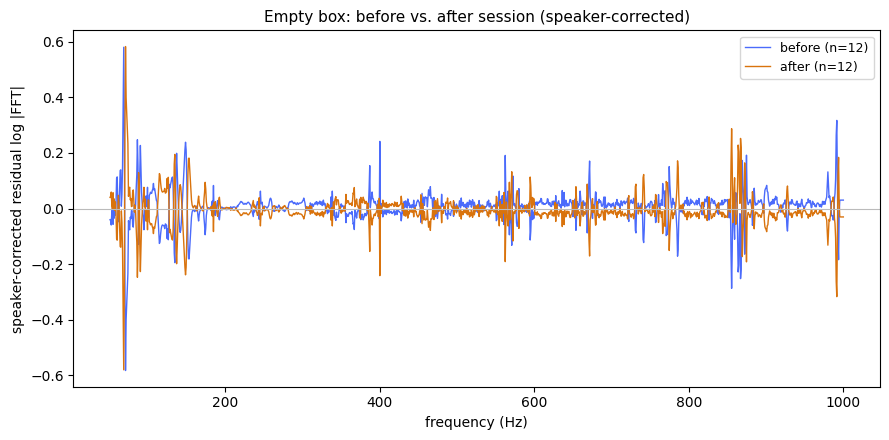

In [9]:
before_mask = empty_mask & df["position_id"].isin([1, 2, 3]).to_numpy()
after_mask = empty_mask & df["position_id"].isin([141, 142, 143]).to_numpy()
print(f"before: {before_mask.sum()} samples, after: {after_mask.sum()} samples")

# RESID is already per-speaker baseline-subtracted, so this comparison is automatically
# paired by speaker (each speaker's own before/after residuals are on the same scale).
before_mean, after_mean = RESID[before_mask].mean(0), RESID[after_mask].mean(0)
between_dist = rms_dist(before_mean, after_mean)
within_before = rms_dist(RESID[before_mask], before_mean).mean()
within_after = rms_dist(RESID[after_mask], after_mean).mean()
noise_floor = (within_before + within_after) / 2

D2_ba = sq_dist_matrix(RESID[before_mask | after_mask])
labels_ba = np.where(df.loc[before_mask | after_mask, "position_id"].isin([1, 2, 3]), "before", "after")
F_ba, R2_ba, p_ba = permanova(D2_ba, labels_ba, n_perm=999)

print(f"before-vs-after distance:      {between_dist:.4f}")
print(f"within-half noise floor:       {noise_floor:.4f}")
print(f"ratio (signal / noise floor):  {between_dist / noise_floor:.2f}x")
print(f"PERMANOVA before vs after:     R^2={R2_ba:.3f}  p={p_ba:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(FREQS, before_mean, lw=1, color="#4b6bfb", label=f"before (n={before_mask.sum()})")
ax.plot(FREQS, after_mean, lw=1, color="#d9730d", label=f"after (n={after_mask.sum()})")
ax.axhline(0, color="#bbb", lw=0.8)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("speaker-corrected residual log |FFT|")
ax.set_title("Empty box: before vs. after session (speaker-corrected)", fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

**Cosine caveat for this specific comparison**: each speaker's baseline is the mean of
its 3 before-samples and 3 after-samples pooled, so by construction
`before_mean == -after_mean` exactly in residual space. Under cosine distance that
forces `1 - cos(before_mean, after_mean) = 2.0` (perfectly anti-parallel) regardless
of the actual data — it's a mathematical artifact of centering on the combined
before/after mean, not a measurement. **Trust the Euclidean number for Q2**; cosine
is fine for the other sections (Q1, Q4, Q5), where the compared vectors aren't
constructed to be exact opposites of each other.

# 6 Q3 — coffee pot: how does the signal change as we move it around?

The coffee pot has 7 positions: 4 corners of the box + 3 tightly-clustered points
near the center. For each position, RMS log-magnitude distance from the coffee pot's
own overall mean spectrum, plotted spatially (marker size/color = distance) and as a
bar chart ordered by distance from the box center.

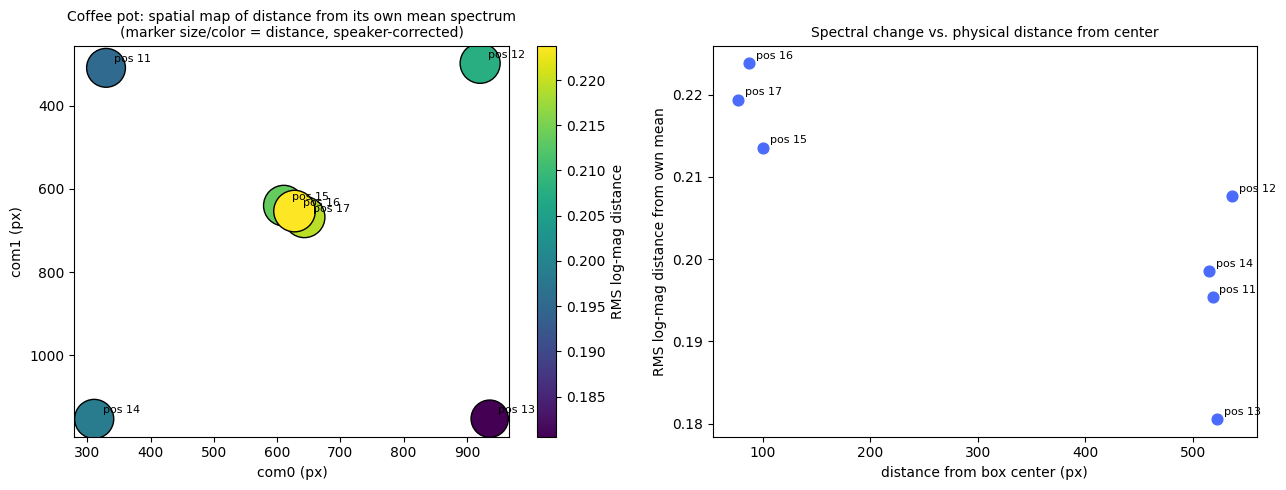

,position_id,com0,com1,dist_from_own_mean,dist_from_center_px
2,13,936.123674,1153.077534,0.180561,522.150608
0,11,329.428852,308.538649,0.195342,518.340788
3,14,310.692323,1153.658720,0.198591,514.927708
1,12,920.964586,297.657303,0.207685,536.503445
4,15,610.585763,640.173607,0.213557,99.804151
6,17,643.026154,667.732503,0.219402,76.582032
5,16,627.494016,653.354701,0.223812,87.045069


In [10]:
cp_mask = (df["object_type"] == "coffee pot").to_numpy()
cp_mean = RESID[cp_mask].mean(axis=0)
df.loc[cp_mask, "dist_from_own_mean"] = rms_dist(RESID[cp_mask], cp_mean)

cp_pos = (df[cp_mask].groupby(["position_id", "com0", "com1"])["dist_from_own_mean"]
          .mean().reset_index().sort_values("dist_from_own_mean"))
box_center = np.array([df["com0"].mean(), df["com1"].mean()])
cp_pos["dist_from_center_px"] = np.hypot(cp_pos["com0"] - box_center[0], cp_pos["com1"] - box_center[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(cp_pos["com0"], cp_pos["com1"], s=cp_pos["dist_from_own_mean"] * 4000,
                 c=cp_pos["dist_from_own_mean"], cmap="viridis", edgecolors="k")
for _, r in cp_pos.iterrows():
    ax.annotate(f"pos {int(r.position_id)}", (r.com0, r.com1), fontsize=8,
                xytext=(6, 4), textcoords="offset points")
ax.invert_yaxis()
ax.set_xlabel("com0 (px)"); ax.set_ylabel("com1 (px)")
ax.set_title("Coffee pot: spatial map of distance from its own mean spectrum\n(marker size/color = distance, speaker-corrected)", fontsize=10)
fig.colorbar(sc, ax=ax, label="RMS log-mag distance")

ax = axes[1]
ax.scatter(cp_pos["dist_from_center_px"], cp_pos["dist_from_own_mean"], s=60, color="#4b6bfb")
for _, r in cp_pos.iterrows():
    ax.annotate(f"pos {int(r.position_id)}", (r.dist_from_center_px, r.dist_from_own_mean),
                fontsize=8, xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("distance from box center (px)")
ax.set_ylabel("RMS log-mag distance from own mean")
ax.set_title("Spectral change vs. physical distance from center", fontsize=10)
fig.tight_layout()
plt.show()

cp_pos

# 7 Q5 — do all objects look the same near the center? How consistent?

Every object has 3 near-center positions (identified as its 3 positions closest to
the overall box centroid). We compare:

- **within-object spread at center**: distance of each object's 3 center positions
  (x4 speakers) from that object's own center-mean — the measurement noise floor.
- **across-object spread at center**: distance of each object's center-mean spectrum
  from the grand center-mean (over all 19 objects) — how much objects actually differ
  from each other when sitting at roughly the same spot.

The **ratio** of these two numbers is the headline consistency metric: close to 1x
means the center signal is essentially the same for every object (position dominates,
object identity is invisible there); much greater than 1x means objects remain
distinguishable even at the center.

228 near-center samples across 19 objects


within-object spread at center (noise floor): 0.2088
across-object spread at center:                0.0821
consistency ratio (across / within):           0.39x
PERMANOVA object-type at center:                R^2=0.136  p=0.0010


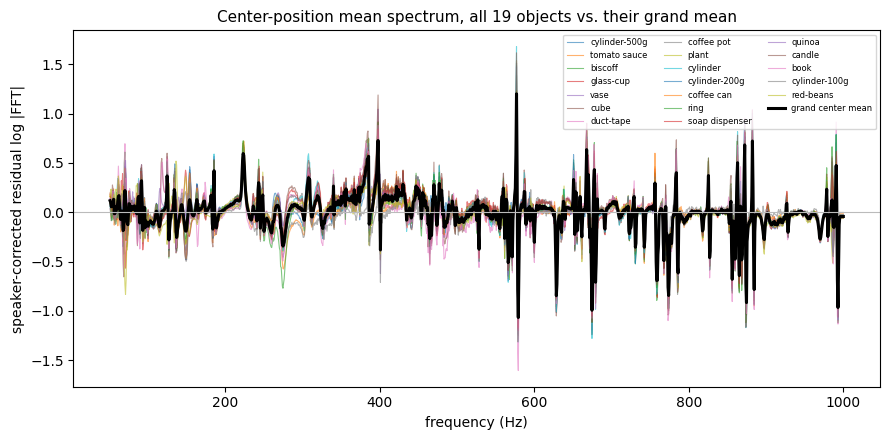

In [11]:
df["dist_from_box_center_px"] = np.hypot(df["com0"] - box_center[0], df["com1"] - box_center[1])

center_idx = []
for obj, g in df[obj_mask].groupby("object_type"):
    pos_dist = g.groupby("position_id")["dist_from_box_center_px"].mean().nsmallest(3)
    center_idx += g[g["position_id"].isin(pos_dist.index)].index.tolist()
center_idx = np.array(sorted(center_idx))
center_mask = np.zeros(len(df), dtype=bool)
center_mask[center_idx] = True
print(f"{center_mask.sum()} near-center samples across {df.loc[center_mask, 'object_type'].nunique()} objects")

per_obj_center_mean = {}
within_center = []
for obj, g in df[center_mask].groupby("object_type"):
    idx = g.index.to_numpy()
    m = RESID[idx].mean(axis=0)
    per_obj_center_mean[obj] = m
    within_center.append(rms_dist(RESID[idx], m).mean())
within_center = np.mean(within_center)

center_means = np.stack(list(per_obj_center_mean.values()))
grand_center_mean = center_means.mean(axis=0)
across_center = rms_dist(center_means, grand_center_mean).mean()

D2_center = sq_dist_matrix(RESID[center_mask])
F_c, R2_c, p_c = permanova(D2_center, df.loc[center_mask, "object_type"].to_numpy())

print(f"within-object spread at center (noise floor): {within_center:.4f}")
print(f"across-object spread at center:                {across_center:.4f}")
print(f"consistency ratio (across / within):           {across_center / within_center:.2f}x")
print(f"PERMANOVA object-type at center:                R^2={R2_c:.3f}  p={p_c:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
order = sorted(per_obj_center_mean, key=lambda o: rms_dist(per_obj_center_mean[o], grand_center_mean))
for obj in order:
    ax.plot(FREQS, per_obj_center_mean[obj], lw=0.8, alpha=0.6, label=obj)
ax.plot(FREQS, grand_center_mean, lw=2.2, color="black", label="grand center mean")
ax.axhline(0, color="#bbb", lw=0.8)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("speaker-corrected residual log |FFT|")
ax.set_title("Center-position mean spectrum, all 19 objects vs. their grand mean", fontsize=11)
ax.legend(fontsize=6, ncol=3, loc="upper right")
fig.tight_layout()
plt.show()

**Caveat on the 0.39x ratio**: "within" is a per-sample spread (noise on individual
12-sample groups) while "across" is a spread of already-averaged 19 group means, which
is intrinsically smoother — so the two aren't perfectly apples-to-apples and the raw
ratio understates how distinguishable objects are at center. The **PERMANOVA R^2=0.136,
p=0.001** above is the more defensible single number: object identity explains ~14% of
the variance even at the center (real and significant, but modest — most of the
center-position spectrum genuinely looks similar across objects).

# 8 Robustness check: does keeping the laser axis reveal more signal?

`notebooks/77_box_datasets.ipynb` (section 4) warns that averaging `|FFT|` over all
100 lasers dilutes an object's (localized) footprint by ~1/L, since only a handful of
lasers near the object actually respond. Now that the speaker confound is controlled
for, we check whether preserving the laser axis (only averaging the 2 xy channels)
reveals a stronger object-vs-empty separation than the fully-averaged spectrum used
throughout this notebook.

In [12]:
logmag_lc = []       # log|FFT| averaged over xy channel only, laser axis kept: (N, L*F)
for sample_id in df["sample_id"]:
    fp = SAMPLES_DIR / str(sample_id) / "vibration/04_ffts.npz"
    with np.load(fp) as z:
        mag_lc = np.abs(z["fft"][0]).mean(axis=2)     # (L,F,C) -> (L,F)
    logmag_lc.append(to_logmag(mag_lc).ravel())
LOGMAG_LC = np.stack(logmag_lc)                        # (N, 100*1235)

# speaker-correct this representation too, same recipe as RESID
empty_mean_lc_by_speaker = {
    s: LOGMAG_LC[empty_mask & (df["speaker"] == s).to_numpy()].mean(axis=0)
    for s in sorted(df["speaker"].unique())
}
speaker_baseline_lc = np.stack([empty_mean_lc_by_speaker[s] for s in df["speaker"]])

dist_avgL = rms_dist(LOGMAG, speaker_baseline)          # what section 3-7 use (avg over lasers, speaker-corrected)
dist_keepL = rms_dist(LOGMAG_LC, speaker_baseline_lc)   # laser axis preserved, speaker-corrected

for name, dist in [("avg-over-lasers (used above)", dist_avgL), ("laser-axis-preserved", dist_keepL)]:
    print(f"{name:32s} empty mean dist={dist[empty_mask].mean():.3f}  "
          f"object mean dist={dist[obj_mask].mean():.3f}  "
          f"ratio(obj/empty)={dist[obj_mask].mean() / dist[empty_mask].mean():.2f}x")

avg-over-lasers (used above)     empty mean dist=0.118  object mean dist=0.250  ratio(obj/empty)=2.12x
laser-axis-preserved             empty mean dist=0.265  object mean dist=0.393  ratio(obj/empty)=1.48x


**Verdict**: once the speaker confound is removed, averaging over all 100 lasers
(2.12x) actually separates objects from the empty box *better* than preserving the
laser axis (1.48x) — the extra 100x dimensionality of the laser-preserved
representation inflates its own empty-box noise floor (0.265 vs 0.118) more than it
recovers signal. So the nb77 dilution concern doesn't hold here once speaker is
controlled for; the averaged representation used throughout sections 3-7 is fine.

# 9 Summary

| # | Question | Answer |
|---|----------|--------|
| 1 | Position vs. object type | **Position shifts the signal more.** Nested PERMANOVA: position-within-object R^2=0.262 (mean, significant for 6/19 objects) vs. between-object R^2=0.074 (p=0.001). Where you place *anything* moves the spectrum ~3.5x more than what you place. |
| 2 | Empty box before vs. after | **Real, significant drift.** Distance 0.117 vs. within-half noise floor 0.102 (1.15x); PERMANOVA R^2=0.230, p=0.001. Small in absolute terms but not noise — the box's own baseline shifted over the ~2-hour session. |
| 3 | Coffee pot across positions | See the section-6 table/plot — corner positions move the spectrum measurably more than the 3 near-center replicates move relative to each other (spatial map above). |
| 4 | Most / least different from empty box | **Most:** `book` (0.314). **Least:** `red-beans` (0.200). Empty-box noise floor is 0.118, so even the least-different object is clearly above noise (~1.7x). |
| 5 | Center consistency | Objects are fairly, but not perfectly, similar at the center: PERMANOVA R^2=0.136 (p=0.001) — object identity explains ~14% of the center-position variance, the rest (~86%) is shared/consistent across objects. |

**Biggest surprise, and the one thing to fix before trusting any of this further**:
speaker identity (which of 4 excitation sources fired) explains **R^2=0.88** of the
raw variance — far more than object or position. Every number above is computed on
speaker-corrected residuals (subtracting each speaker's own empty-box mean); without
that correction, sections 3-7 would have shown near-zero effects for everything, which
was the initial (wrong) result. Any future analysis of this dataset should apply the
same speaker correction (or fix `speaker` in the query, as `notebooks/77_box_datasets.ipynb`
does) before comparing objects or positions.